# EDA for TravelTide

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns

## Users

In [3]:
df_users = pd.read_csv("data/raw_data/users.csv")
df_users

,user_id,birthdate,gender,married,has_children,home_country,home_city,home_airport,home_airport_lat,home_airport_lon,sign_up_date
0,94883,1972-03-16,F,True,False,usa,kansas city,MCI,39.297,-94.714,2022-02-07
1,101486,1972-12-07,F,True,True,usa,tacoma,TCM,47.138,-122.476,2022-02-17
2,101961,1980-09-14,F,True,False,usa,boston,BOS,42.364,-71.005,2022-02-17
3,106907,1978-11-17,F,True,True,usa,miami,TNT,25.862,-80.897,2022-02-24
4,118043,1972-05-04,F,False,True,usa,los angeles,LAX,33.942,-118.408,2022-03-10
...,...,...,...,...,...,...,...,...,...,...,...
5777,780167,1974-06-08,F,True,True,usa,los angeles,LAX,33.942,-118.408,2023-04-25
5778,785186,1979-06-03,F,True,True,usa,little rock,LIT,34.729,-92.224,2023-04-27
5779,792549,1978-01-25,F,False,False,usa,kansas city,MCI,39.297,-94.714,2023-04-30
5780,811077,1979-02-22,F,True,True,usa,knoxville,TYS,35.812,-83.993,2023-05-06


In [4]:
df_users["birthdate"] = pd.to_datetime(df_users["birthdate"]) # Funktion to_datetime wandelt einen Wert (in dem Fall Str) in ein Datum Format um.

In [5]:
df_users

,user_id,birthdate,gender,married,has_children,home_country,home_city,home_airport,home_airport_lat,home_airport_lon,sign_up_date
0,94883,1972-03-16,F,True,False,usa,kansas city,MCI,39.297,-94.714,2022-02-07
1,101486,1972-12-07,F,True,True,usa,tacoma,TCM,47.138,-122.476,2022-02-17
2,101961,1980-09-14,F,True,False,usa,boston,BOS,42.364,-71.005,2022-02-17
3,106907,1978-11-17,F,True,True,usa,miami,TNT,25.862,-80.897,2022-02-24
4,118043,1972-05-04,F,False,True,usa,los angeles,LAX,33.942,-118.408,2022-03-10
...,...,...,...,...,...,...,...,...,...,...,...
5777,780167,1974-06-08,F,True,True,usa,los angeles,LAX,33.942,-118.408,2023-04-25
5778,785186,1979-06-03,F,True,True,usa,little rock,LIT,34.729,-92.224,2023-04-27
5779,792549,1978-01-25,F,False,False,usa,kansas city,MCI,39.297,-94.714,2023-04-30
5780,811077,1979-02-22,F,True,True,usa,knoxville,TYS,35.812,-83.993,2023-05-06


In [6]:
pd.Timestamp.today() - df_users["birthdate"]  # wandelt den Zeitraum um.

0      19929 days 09:25:06.574079
1      19663 days 09:25:06.574079
2      16825 days 09:25:06.574079
3      17492 days 09:25:06.574079
4      19880 days 09:25:06.574079
                  ...            
5777   19115 days 09:25:06.574079
5778   17294 days 09:25:06.574079
5779   17788 days 09:25:06.574079
5780   17395 days 09:25:06.574079
5781    9648 days 09:25:06.574079
Name: birthdate, Length: 5782, dtype: timedelta64[us]

In [7]:
(pd.Timestamp.today() - df_users["birthdate"]).dt.days //365  # Befehl .dt.days greift auf die Df und lässt nur Tage übrig.

0       54
1       53
2       46
3       47
4       54
        ..
5777    52
5778    47
5779    48
5780    47
5781    26
Name: birthdate, Length: 5782, dtype: int64

### Erstellung neuer Spalte "age"

In [8]:
df_users["age"] = (pd.Timestamp.today() - df_users["birthdate"]).dt.days //365

In [9]:
df_users

,user_id,birthdate,gender,married,has_children,home_country,home_city,home_airport,home_airport_lat,home_airport_lon,sign_up_date,age
0,94883,1972-03-16,F,True,False,usa,kansas city,MCI,39.297,-94.714,2022-02-07,54
1,101486,1972-12-07,F,True,True,usa,tacoma,TCM,47.138,-122.476,2022-02-17,53
2,101961,1980-09-14,F,True,False,usa,boston,BOS,42.364,-71.005,2022-02-17,46
3,106907,1978-11-17,F,True,True,usa,miami,TNT,25.862,-80.897,2022-02-24,47
4,118043,1972-05-04,F,False,True,usa,los angeles,LAX,33.942,-118.408,2022-03-10,54
...,...,...,...,...,...,...,...,...,...,...,...,...
5777,780167,1974-06-08,F,True,True,usa,los angeles,LAX,33.942,-118.408,2023-04-25,52
5778,785186,1979-06-03,F,True,True,usa,little rock,LIT,34.729,-92.224,2023-04-27,47
5779,792549,1978-01-25,F,False,False,usa,kansas city,MCI,39.297,-94.714,2023-04-30,48
5780,811077,1979-02-22,F,True,True,usa,knoxville,TYS,35.812,-83.993,2023-05-06,47


<Axes: xlabel='age', ylabel='Count'>

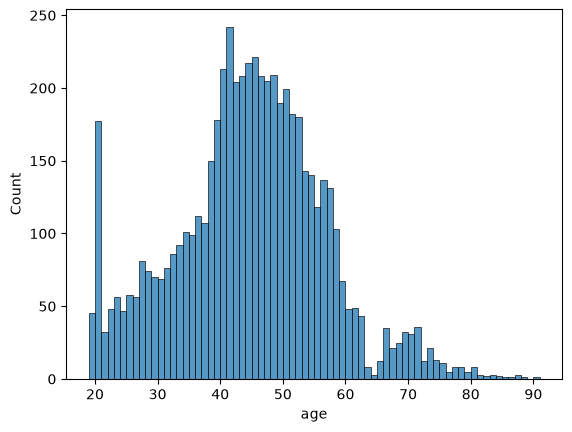

In [10]:
sns.histplot(df_users, x= "age", binwidth = 1)

In [11]:
df_users.describe()

,user_id,birthdate,home_airport_lat,home_airport_lon,age
count,5782.000000,5782,5782.000000,5782.000000,5782.000000
mean,547670.236077,1982-02-22 03:35:55.517122,38.449324,-94.158017,44.170702
min,94883.000000,1935-05-10 00:00:00,21.316000,-157.927000,19.000000
25%,519413.750000,1974-09-07 00:00:00,33.818000,-112.289250,37.000000
50%,542279.500000,1981-10-25 12:00:00,39.175000,-90.035000,44.000000
75%,576215.500000,1989-03-17 18:00:00,42.276000,-79.370000,52.000000
max,844489.000000,2006-12-28 00:00:00,61.251000,-63.499000,91.000000
std,64035.394540,NaN,6.199542,18.070420,12.050078


In [12]:
df_users.to_csv("data/data_preprocessed/users_preprocessed.csv", index=False)

# Sign up Year

In [13]:
df_users["sign_up_date"] = pd.to_datetime(df_users["sign_up_date"])

In [14]:
df_users["sign_up_year"] = df_users["sign_up_date"].dt.year

In [15]:
df_users["sign_up_year"].value_counts()

sign_up_year
2023    5167
2022     615
Name: count, dtype: int64

In [16]:
sign_up_year = df_users["sign_up_year"].value_counts()

In [17]:
df_users["sign_up_year"]

0       2022
1       2022
2       2022
3       2022
4       2022
        ... 
5777    2023
5778    2023
5779    2023
5780    2023
5781    2023
Name: sign_up_year, Length: 5782, dtype: int32

In [18]:
df_users

,user_id,birthdate,gender,married,has_children,home_country,home_city,home_airport,home_airport_lat,home_airport_lon,sign_up_date,age,sign_up_year
0,94883,1972-03-16,F,True,False,usa,kansas city,MCI,39.297,-94.714,2022-02-07,54,2022
1,101486,1972-12-07,F,True,True,usa,tacoma,TCM,47.138,-122.476,2022-02-17,53,2022
2,101961,1980-09-14,F,True,False,usa,boston,BOS,42.364,-71.005,2022-02-17,46,2022
3,106907,1978-11-17,F,True,True,usa,miami,TNT,25.862,-80.897,2022-02-24,47,2022
4,118043,1972-05-04,F,False,True,usa,los angeles,LAX,33.942,-118.408,2022-03-10,54,2022
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5777,780167,1974-06-08,F,True,True,usa,los angeles,LAX,33.942,-118.408,2023-04-25,52,2023
5778,785186,1979-06-03,F,True,True,usa,little rock,LIT,34.729,-92.224,2023-04-27,47,2023
5779,792549,1978-01-25,F,False,False,usa,kansas city,MCI,39.297,-94.714,2023-04-30,48,2023
5780,811077,1979-02-22,F,True,True,usa,knoxville,TYS,35.812,-83.993,2023-05-06,47,2023


In [19]:
df_users.to_csv("data/data_preprocessed/users_preprocessed.csv", index=False)

# Sessions

In [20]:
df_sessions = pd.read_csv("data/raw_data/sessions.csv")
df_sessions

,session_id,user_id,trip_id,session_start,session_end,flight_discount,hotel_discount,flight_discount_amount,hotel_discount_amount,flight_booked,hotel_booked,page_clicks,cancellation
0,474007-3f94a8eeac6441768dbcc9e138150ad1,474007,NaN,2023-02-14 12:12:00,2023-02-14 12:12:30,False,False,NaN,NaN,False,False,4,False
1,476124-0a2b1fe2cd8445749421d95afc686201,476124,NaN,2023-02-14 21:47:00,2023-02-14 21:47:45,False,False,NaN,NaN,False,False,6,False
2,486605-78e96c1b97af4a078d41bfa3697004ca,486605,NaN,2023-02-14 19:20:00,2023-02-14 19:20:39,False,True,NaN,0.20,False,False,5,False
3,486751-997cd295ede648dbabf6c45d54c9f2f5,486751,NaN,2023-02-14 13:22:00,2023-02-14 13:23:06,False,False,NaN,NaN,False,False,9,False
4,488099-18cbf909cfc246b3978c42042ea8bd14,488099,NaN,2023-02-14 22:26:00,2023-02-14 22:26:29,False,False,NaN,NaN,False,False,4,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
48678,445351-53e733391f4f49b2b819b3c9fbdf639e,445351,445351-7946218c0beb4822afd82636ab495f4f,2023-02-14 14:16:00,2023-02-14 14:20:34,False,True,NaN,0.20,True,True,36,False
48679,445515-c77a953bee954480bfba1cd9e4548225,445515,NaN,2023-02-14 19:21:00,2023-02-14 19:23:24,False,False,NaN,NaN,False,False,20,False
48680,447053-0de75caa6dba4aa0b2066cc1bb5363e6,447053,NaN,2023-02-14 06:05:00,2023-02-14 06:05:59,False,False,NaN,NaN,False,False,8,False
48681,450305-7e1c13467e0b4f6996968a36250e7f93,450305,NaN,2023-02-14 02:20:00,2023-02-14 02:22:21,False,False,NaN,NaN,False,False,19,False


In [21]:
df_sessions.to_csv("data/data_preprocessed/sessions_preprocessed.csv", index=False)

In [22]:
#df_sessions.groupby()

# Hotels

In [23]:
df_hotels = pd.read_csv("data/raw_data/hotels.csv")
df_hotels

,trip_id,hotel_name,nights,rooms,check_in_time,check_out_time,hotel_per_room_usd
0,574465-ff51972344c041fa97c9eb8bcc071cb4,Best Western - portland,0,1,2023-04-22 15:30:48.96,2023-04-23 11:00:00,366
1,596361-cf65c7c360a4431b9ca9605c74a94e73,InterContinental - dallas,11,1,2023-04-18 17:54:37.935,2023-04-30 11:00:00,179
2,540572-5a836a394a8a4cd7a1bba7f0e7eb0494,Four Seasons - edmonton,3,1,2023-04-27 15:48:00.945,2023-05-01 11:00:00,148
3,482264-e73c1866d23d4c9082893cfcaf77d13f,Radisson - new york,8,1,2023-04-20 11:33:32.4,2023-04-28 11:00:00,208
4,454934-2b0809d98c0a466ab8f1502d8c229ffc,Best Western - calgary,1,1,2023-04-24 17:56:46.095,2023-04-26 11:00:00,220
...,...,...,...,...,...,...,...
14369,532365-7d2445685a43412d997f5195603a7030,Aman Resorts - dallas,5,3,2023-04-16 10:09:15.525,2023-04-21 11:00:00,130
14370,516251-bcf75616755f4cd7ba29c15d5dd1caf6,Choice Hotels - washington,0,1,2023-04-17 18:57:40.05,2023-04-18 11:00:00,140
14371,517675-49cc5226a9db4f80845e2765563d99c5,Aman Resorts - los angeles,3,1,2023-04-18 18:23:25.53,2023-04-22 11:00:00,122
14372,521743-07935a4ea37b4fc0aee940d8cee5062b,Radisson - tucson,1,1,2023-04-17 13:39:11.205,2023-04-19 11:00:00,191


In [24]:
df_neg_hotels = df_hotels[df_hotels["nights"]< 0]
df_neg_hotels

,trip_id,hotel_name,nights,rooms,check_in_time,check_out_time,hotel_per_room_usd
13,524211-60b3eb9ff20b48fd9011064718a0d007,NH Hotel - ottawa,-1,1,2023-04-29 14:40:43.05,2023-04-29 11:00:00,245
100,665593-258e19907f8f40f08a502f8754990d5c,Choice Hotels - los angeles,-1,2,2023-07-07 14:11:49.38,2023-07-07 11:00:00,122
227,562886-56c06ef71df34257ad92c4af48227fd8,Aman Resorts - los angeles,-1,1,2023-02-05 12:40:44.535,2023-02-05 11:00:00,127
339,372970-10c42843088b49a6bbb6868fbec5abb0,Rosewood - portland,-1,1,2023-03-12 13:34:49.935,2023-03-12 11:00:00,132
439,602598-22e0198df949454b92c7ee3f00d103f5,Conrad - charlotte,-1,3,2023-05-02 10:05:37.23,2023-05-01 11:00:00,206
...,...,...,...,...,...,...,...
13588,530724-935e71d36d5441028c6d61ac3b5e5606,Hyatt - chicago,-1,1,2023-07-26 12:53:27.87,2023-07-26 11:00:00,160
13593,359653-faebca63fc744dbf821f4c2d658a1ca3,Best Western - phoenix,-1,1,2022-10-20 11:23:32.055,2022-10-19 11:00:00,211
14043,665329-5982cd8252ab4d7d95726beadd67f89e,Fairmont - columbus,-1,2,2023-07-04 14:57:38.25,2023-07-04 11:00:00,91
14112,517732-9f5d6a62cd4647bc93f5d4aa8402d9d5,Crowne Plaza - new york,-1,1,2023-01-19 13:52:45.84,2023-01-19 11:00:00,158


In [25]:
pd.to_datetime(df_hotels["check_out_time"], format="mixed").dt.date

0        2023-04-23
1        2023-04-30
2        2023-05-01
3        2023-04-28
4        2023-04-26
            ...    
14369    2023-04-21
14370    2023-04-18
14371    2023-04-22
14372    2023-04-19
14373    2023-04-24
Name: check_out_time, Length: 14374, dtype: object

In [26]:
pd.to_datetime(df_hotels["check_out_time"], format="mixed") - pd.to_datetime(df_hotels["check_in_time"], format="mixed")

0        0 days 19:29:11.040000
1       11 days 17:05:22.065000
2        3 days 19:11:59.055000
3        7 days 23:26:27.600000
4        1 days 17:03:13.905000
                  ...          
14369    5 days 00:50:44.475000
14370    0 days 16:02:19.950000
14371    3 days 16:36:34.470000
14372    1 days 21:20:48.795000
14373    2 days 15:03:47.115000
Length: 14374, dtype: timedelta64[us]

### Ersatz von '- Nächten' auf 1 Nacht

In [27]:
df_hotels.loc[df_hotels["nights"]<0, "nights"] = 1

In [28]:
df_hotels

,trip_id,hotel_name,nights,rooms,check_in_time,check_out_time,hotel_per_room_usd
0,574465-ff51972344c041fa97c9eb8bcc071cb4,Best Western - portland,0,1,2023-04-22 15:30:48.96,2023-04-23 11:00:00,366
1,596361-cf65c7c360a4431b9ca9605c74a94e73,InterContinental - dallas,11,1,2023-04-18 17:54:37.935,2023-04-30 11:00:00,179
2,540572-5a836a394a8a4cd7a1bba7f0e7eb0494,Four Seasons - edmonton,3,1,2023-04-27 15:48:00.945,2023-05-01 11:00:00,148
3,482264-e73c1866d23d4c9082893cfcaf77d13f,Radisson - new york,8,1,2023-04-20 11:33:32.4,2023-04-28 11:00:00,208
4,454934-2b0809d98c0a466ab8f1502d8c229ffc,Best Western - calgary,1,1,2023-04-24 17:56:46.095,2023-04-26 11:00:00,220
...,...,...,...,...,...,...,...
14369,532365-7d2445685a43412d997f5195603a7030,Aman Resorts - dallas,5,3,2023-04-16 10:09:15.525,2023-04-21 11:00:00,130
14370,516251-bcf75616755f4cd7ba29c15d5dd1caf6,Choice Hotels - washington,0,1,2023-04-17 18:57:40.05,2023-04-18 11:00:00,140
14371,517675-49cc5226a9db4f80845e2765563d99c5,Aman Resorts - los angeles,3,1,2023-04-18 18:23:25.53,2023-04-22 11:00:00,122
14372,521743-07935a4ea37b4fc0aee940d8cee5062b,Radisson - tucson,1,1,2023-04-17 13:39:11.205,2023-04-19 11:00:00,191


## City name split

In [29]:
df_hotels["hotel_name"].str.split(" - ")

0           [Best Western, portland]
1        [InterContinental , dallas]
2           [Four Seasons, edmonton]
3              [Radisson , new york]
4            [Best Western, calgary]
                    ...             
14369         [Aman Resorts, dallas]
14370    [Choice Hotels, washington]
14371    [Aman Resorts, los angeles]
14372            [Radisson , tucson]
14373          [Marriott , new york]
Name: hotel_name, Length: 14374, dtype: object

In [30]:
df_hotels["hotel_name"].str.split(" - ", expand=True)

,0,1
0,Best Western,portland
1,InterContinental,dallas
2,Four Seasons,edmonton
3,Radisson,new york
4,Best Western,calgary
...,...,...
14369,Aman Resorts,dallas
14370,Choice Hotels,washington
14371,Aman Resorts,los angeles
14372,Radisson,tucson


### Überschreiben wir auf Hotel_name und hotel_city

In [31]:
df_hotels[["hotel_name", "hotel_city"]] = df_hotels["hotel_name"].str.split(" - ", expand=True)

In [32]:
df_hotels

,trip_id,hotel_name,nights,rooms,check_in_time,check_out_time,hotel_per_room_usd,hotel_city
0,574465-ff51972344c041fa97c9eb8bcc071cb4,Best Western,0,1,2023-04-22 15:30:48.96,2023-04-23 11:00:00,366,portland
1,596361-cf65c7c360a4431b9ca9605c74a94e73,InterContinental,11,1,2023-04-18 17:54:37.935,2023-04-30 11:00:00,179,dallas
2,540572-5a836a394a8a4cd7a1bba7f0e7eb0494,Four Seasons,3,1,2023-04-27 15:48:00.945,2023-05-01 11:00:00,148,edmonton
3,482264-e73c1866d23d4c9082893cfcaf77d13f,Radisson,8,1,2023-04-20 11:33:32.4,2023-04-28 11:00:00,208,new york
4,454934-2b0809d98c0a466ab8f1502d8c229ffc,Best Western,1,1,2023-04-24 17:56:46.095,2023-04-26 11:00:00,220,calgary
...,...,...,...,...,...,...,...,...
14369,532365-7d2445685a43412d997f5195603a7030,Aman Resorts,5,3,2023-04-16 10:09:15.525,2023-04-21 11:00:00,130,dallas
14370,516251-bcf75616755f4cd7ba29c15d5dd1caf6,Choice Hotels,0,1,2023-04-17 18:57:40.05,2023-04-18 11:00:00,140,washington
14371,517675-49cc5226a9db4f80845e2765563d99c5,Aman Resorts,3,1,2023-04-18 18:23:25.53,2023-04-22 11:00:00,122,los angeles
14372,521743-07935a4ea37b4fc0aee940d8cee5062b,Radisson,1,1,2023-04-17 13:39:11.205,2023-04-19 11:00:00,191,tucson


In [33]:
df_hotels["hotel_name"].nunique()

20

In [34]:
df_hotels["hotel_city"].nunique()

101

In [35]:
df_temp = df_hotels["hotel_city"].value_counts() # speichern wir vorübergehen als df_temp um die daten in datawrangler zu sehen

In [36]:
df_temp

hotel_city
new york        2122
los angeles     1064
toronto          757
chicago          749
houston          602
                ... 
pune               1
jakarta            1
buenos aires       1
prague             1
atlanta            1
Name: count, Length: 101, dtype: int64

In [37]:
df_hotels.to_csv("data/data_preprocessed/hotels_preprocessed.csv", index=False)

## high - low season analysis

In [38]:
df_hotels["check_in_time"] = pd.to_datetime(df_hotels["check_in_time"], format= 'mixed')

In [39]:
df_hotels["month"] = df_hotels["check_in_time"].dt.month

<Axes: xlabel='month', ylabel='hotel_per_room_usd'>

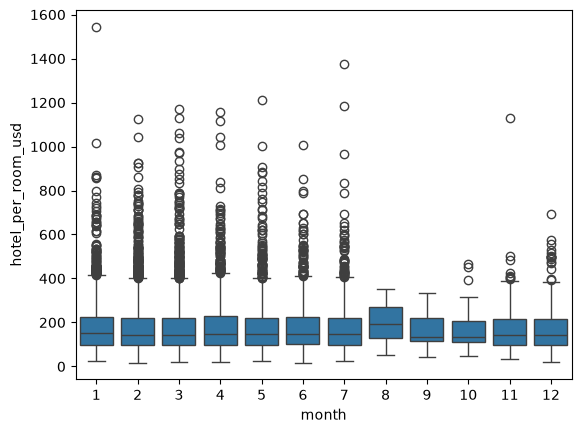

In [40]:
sns.boxplot(df_hotels, x= "month", y= "hotel_per_room_usd")

### wieviele buchungen waren in monaten

<Axes: xlabel='month', ylabel='count'>

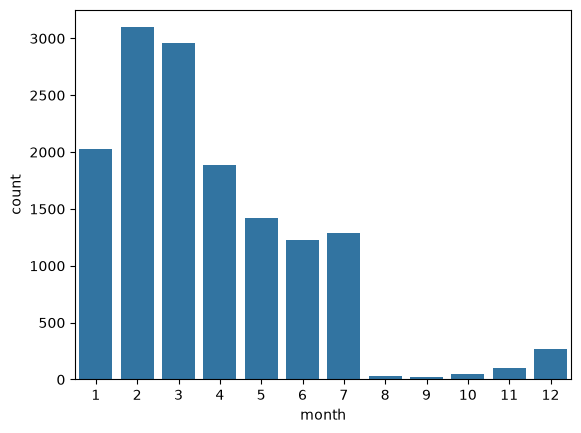

In [41]:
sns.countplot(df_hotels, x="month")

<Axes: xlabel='month', ylabel='count'>

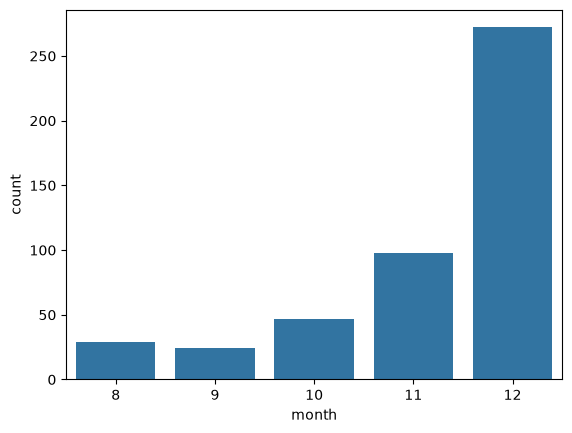

In [42]:
sns.countplot(df_hotels[df_hotels["month"]>=8], x="month")

# Flights

In [43]:
df_flights = pd.read_csv("data/raw_data/flights.csv")
df_flights

,trip_id,origin_airport,destination,destination_airport,seats,return_flight_booked,departure_time,return_time,checked_bags,trip_airline,destination_airport_lat,destination_airport_lon,base_fare_usd
0,521884-9845e75d6a684cf0b11e4e109f52aff1,LRF,portland,PDX,3,True,2023-01-17 11:00:00,2023-01-20 11:00:00,1,Virgin America,45.589,-122.597,1477.40
1,522607-a1c478eb7e1543df801f670df2ec48b3,MIA,austin,AUS,1,True,2023-01-19 07:00:00,2023-01-24 07:00:00,1,Southwest Airlines,30.194,-97.670,326.82
2,526445-7434e7b2ee694e7f801cbdc6b2e87c34,MCF,ottawa,YOW,1,True,2023-01-20 15:00:00,2023-01-23 15:00:00,1,WestJet,45.323,-75.669,371.83
3,434623-e2cbb191fcf94e8c90584c49d7fe2ffd,YHU,new york,JFK,1,True,2023-01-19 16:00:00,2023-01-22 16:00:00,0,Avianca - Aerovias Nacionales de Colombia,40.640,-73.779,97.89
4,525043-4d5e0eb1746a4e0a83969d3072bbecb5,EFD,new york,LGA,1,True,2023-01-18 07:00:00,2023-01-20 07:00:00,0,JetBlue Airways,40.640,-73.779,435.64
...,...,...,...,...,...,...,...,...,...,...,...,...,...
13762,511677-4194ea35bbf1434db5db579434ecc6d8,MEM,philadelphia,PHL,3,True,2023-01-16 13:00:00,2023-01-23 13:00:00,2,American Airlines,39.872,-75.241,740.02
13763,522223-802fad1516bc44cea49788c5837d9517,BNA,edmonton,YEG,1,True,2023-01-15 07:00:00,2023-01-19 07:00:00,1,United Airlines,53.667,-113.467,576.45
13764,521956-3f5c4243e6ef493cbd7a116263dbded8,YTZ,charlotte,CLT,1,True,2023-01-17 13:00:00,2023-01-19 13:00:00,0,Air France,35.214,-80.943,173.56
13765,523090-a2eb200da814491db2d01f92c2c5f204,TUS,toronto,YTZ,1,True,2023-01-22 08:00:00,2023-01-26 08:00:00,1,Porter Airlines,43.862,-79.370,507.09


In [44]:
df_flights["destination"].nunique()

125

# distance km

In [45]:
import airportsdata

In [46]:
# Flughafendaten laden
airports = airportsdata.load("IATA")

# Koordinaten anhand der IATA-Codes holen
df_flights["origin_lat"] = df_flights["origin_airport"].str.upper().map(
    lambda x: airports[x]["lat"] if x in airports else np.nan
)

df_flights["origin_lon"] = df_flights["origin_airport"].str.upper().map(
    lambda x: airports[x]["lon"] if x in airports else np.nan
)

df_flights["destination_lat"] = df_flights["destination_airport"].str.upper().map(
    lambda x: airports[x]["lat"] if x in airports else np.nan
)

df_flights["destination_lon"] = df_flights["destination_airport"].str.upper().map(
    lambda x: airports[x]["lon"] if x in airports else np.nan
)

# Koordinaten in Radiant umwandeln
lat1 = np.radians(df_flights["origin_lat"])
lon1 = np.radians(df_flights["origin_lon"])
lat2 = np.radians(df_flights["destination_lat"])
lon2 = np.radians(df_flights["destination_lon"])

# Haversine-Formel
dlat = lat2 - lat1
dlon = lon2 - lon1

a = (
    np.sin(dlat / 2) ** 2
    + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
)

c = 2 * np.arcsin(np.sqrt(a))

# Entfernung in km
df_flights["distance_km"] = 6371 * c

In [47]:
df_flights

,trip_id,origin_airport,destination,destination_airport,seats,return_flight_booked,departure_time,return_time,checked_bags,trip_airline,destination_airport_lat,destination_airport_lon,base_fare_usd,origin_lat,origin_lon,destination_lat,destination_lon,distance_km
0,521884-9845e75d6a684cf0b11e4e109f52aff1,LRF,portland,PDX,3,True,2023-01-17 11:00:00,2023-01-20 11:00:00,1,Virgin America,45.589,-122.597,1477.40,34.917510,-92.145001,45.588709,-122.596869,2821.159263
1,522607-a1c478eb7e1543df801f670df2ec48b3,MIA,austin,AUS,1,True,2023-01-19 07:00:00,2023-01-24 07:00:00,1,Southwest Airlines,30.194,-97.670,326.82,25.795361,-80.290116,30.194527,-97.669876,1772.999269
2,526445-7434e7b2ee694e7f801cbdc6b2e87c34,MCF,ottawa,YOW,1,True,2023-01-20 15:00:00,2023-01-23 15:00:00,1,WestJet,45.323,-75.669,371.83,27.849344,-82.521219,45.322500,-75.669200,2035.030149
3,434623-e2cbb191fcf94e8c90584c49d7fe2ffd,YHU,new york,JFK,1,True,2023-01-19 16:00:00,2023-01-22 16:00:00,0,Avianca - Aerovias Nacionales de Colombia,40.640,-73.779,97.89,45.517500,-73.416900,40.639928,-73.778692,543.154930
4,525043-4d5e0eb1746a4e0a83969d3072bbecb5,EFD,new york,LGA,1,True,2023-01-18 07:00:00,2023-01-20 07:00:00,0,JetBlue Airways,40.640,-73.779,435.64,29.607333,-95.158750,40.777242,-73.872606,2289.128267
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13762,511677-4194ea35bbf1434db5db579434ecc6d8,MEM,philadelphia,PHL,3,True,2023-01-16 13:00:00,2023-01-23 13:00:00,2,American Airlines,39.872,-75.241,740.02,35.042411,-89.976679,39.872084,-75.240663,1404.998853
13763,522223-802fad1516bc44cea49788c5837d9517,BNA,edmonton,YEG,1,True,2023-01-15 07:00:00,2023-01-19 07:00:00,1,United Airlines,53.667,-113.467,576.45,36.124475,-86.678181,53.309700,-113.580000,2827.435609
13764,521956-3f5c4243e6ef493cbd7a116263dbded8,YTZ,charlotte,CLT,1,True,2023-01-17 13:00:00,2023-01-19 13:00:00,0,Air France,35.214,-80.943,173.56,43.627500,-79.396200,35.213187,-80.951379,945.065947
13765,523090-a2eb200da814491db2d01f92c2c5f204,TUS,toronto,YTZ,1,True,2023-01-22 08:00:00,2023-01-26 08:00:00,1,Porter Airlines,43.862,-79.370,507.09,32.117070,-110.941463,43.627500,-79.396200,3026.210537


In [48]:
df_flights = df_flights.drop(columns=[
    "origin_lat",
    "origin_lon",
    "destination_lat",
    "destination_lon"
])

In [49]:
df_flights

,trip_id,origin_airport,destination,destination_airport,seats,return_flight_booked,departure_time,return_time,checked_bags,trip_airline,destination_airport_lat,destination_airport_lon,base_fare_usd,distance_km
0,521884-9845e75d6a684cf0b11e4e109f52aff1,LRF,portland,PDX,3,True,2023-01-17 11:00:00,2023-01-20 11:00:00,1,Virgin America,45.589,-122.597,1477.40,2821.159263
1,522607-a1c478eb7e1543df801f670df2ec48b3,MIA,austin,AUS,1,True,2023-01-19 07:00:00,2023-01-24 07:00:00,1,Southwest Airlines,30.194,-97.670,326.82,1772.999269
2,526445-7434e7b2ee694e7f801cbdc6b2e87c34,MCF,ottawa,YOW,1,True,2023-01-20 15:00:00,2023-01-23 15:00:00,1,WestJet,45.323,-75.669,371.83,2035.030149
3,434623-e2cbb191fcf94e8c90584c49d7fe2ffd,YHU,new york,JFK,1,True,2023-01-19 16:00:00,2023-01-22 16:00:00,0,Avianca - Aerovias Nacionales de Colombia,40.640,-73.779,97.89,543.154930
4,525043-4d5e0eb1746a4e0a83969d3072bbecb5,EFD,new york,LGA,1,True,2023-01-18 07:00:00,2023-01-20 07:00:00,0,JetBlue Airways,40.640,-73.779,435.64,2289.128267
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13762,511677-4194ea35bbf1434db5db579434ecc6d8,MEM,philadelphia,PHL,3,True,2023-01-16 13:00:00,2023-01-23 13:00:00,2,American Airlines,39.872,-75.241,740.02,1404.998853
13763,522223-802fad1516bc44cea49788c5837d9517,BNA,edmonton,YEG,1,True,2023-01-15 07:00:00,2023-01-19 07:00:00,1,United Airlines,53.667,-113.467,576.45,2827.435609
13764,521956-3f5c4243e6ef493cbd7a116263dbded8,YTZ,charlotte,CLT,1,True,2023-01-17 13:00:00,2023-01-19 13:00:00,0,Air France,35.214,-80.943,173.56,945.065947
13765,523090-a2eb200da814491db2d01f92c2c5f204,TUS,toronto,YTZ,1,True,2023-01-22 08:00:00,2023-01-26 08:00:00,1,Porter Airlines,43.862,-79.370,507.09,3026.210537


In [50]:
df_flights.to_csv("data/data_preprocessed/flights_preprocessed.csv", index=False)